Modèle prédictif de la sensibilité aux allergies, basé sur un Random Forest Classifier, utilisant les colonnes des résultats de biologie regroupées par familles d'allergènes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

# Dans le fichier BRUT, il y a 4,271 lignes. On a nettoyé ce fichier.
# Dans le fichier CLEAN, il y a 4,145 lignes.
db_path = "../data/allergen_chip_challenge.db"

# On va lire les données allergies directement depuis la table dans la base de données :
conn = sqlite3.connect(db_path)

df = pd.read_sql("Select * From allergies_categories", conn)
conn.close()
#on met close car ne se fait pas automatiquement
df.shape

(4145, 19)

In [2]:
# Affichage des 5 premières lignes dans le notebook pour vérification
print("Aperçu du nouveau tableau regroupé par catégories :")
display(df.head())

Aperçu du nouveau tableau regroupé par catégories :


,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,Region,Rural_area,Sensitization,Treatment_of_rhinitis,Treatment_of_asthma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Acariens/Blattes,Aliments,Animaux,Moisissures/Autres,Pollens
0,FHB0001,ISAC_V1,20 à 40,1,11.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.039091,0.000000,0.000000,0.0,0.000000
1,FHB0002,ISAC_V1,40 à 60,0,12.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.000000,2.226000,0.000000,0.0,7.327826
2,FHB0003,ISAC_V1,10 à 20,1,1.0,regionB,0,0,Anti-H1 voie générale,0,Aucun,0,Acariens,Non renseigné,0.000000,0.000000,0.000000,0.0,0.000000
3,FHB0004,ISAC_V1,10 à 20,0,1.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,3.152727,0.593429,0.065455,0.0,11.686087
4,FHB0005,ISAC_V1,20 à 40,0,1.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.000000,0.000000,0.000000,0.0,6.089130


In [3]:
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

In [7]:
left_columns = []
all_cols = df.columns.tolist()

right_columns = []
for i in range(14, 19):
    right_columns.append(all_cols[i])

right_columns


# Taking columns from the left hand, but not the row-id neither the Patient_ID:
for i in range(1, 14):
    left_columns.append(all_cols[i])

left_columns

['Chip_Type',
 'Age',
 'Gender',
 'Blood_Month_sample',
 'Region',
 'Rural_area',
 'Sensitization',
 'Treatment_of_rhinitis',
 'Treatment_of_asthma',
 'Age_of_onsets',
 'Skin_Symptoms',
 'General_cofactors',
 'Treatment_of_atopic_dematitis']

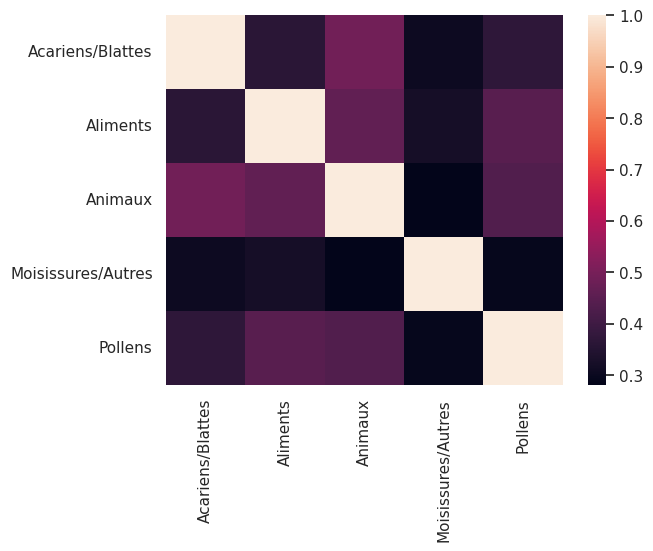

In [ ]:
corr_df = df[right_columns].corr()


# Visualisation des corrélations entre les 5 colonnes synthétiques (à droite de nos colonnes)
# Les 5 colonnes synthétiques, de familles d'allergènes, sont peu corrélées entre elles, ainsi le modèle prédictif sera meilleur.

sns.heatmap(corr_df)
plt.show()

In [9]:
# =====================================================================
# PARTIE A : Initiation au Machine Learning (Exemple avec Scikit-Learn)
# =====================================================================


from sklearn.model_selection import train_test_split

col_that_need_dummies = ['Chip_Type', 'Age', 'Blood_Month_sample', 'Region', 'Treatment_of_rhinitis', 'Age_of_onsets', 'General_cofactors', 'Treatment_of_atopic_dematitis']

# We keep only the columns to keep, and (for the pure categorical columns) we make some dummies.
df2 = df[left_columns + right_columns]
df3 = pd.get_dummies(data=df2, columns=col_that_need_dummies)


# print("--- Préparation du Machine Learning ---")
# Pour faire du ML, on sépare généralement nos données :
# X = les colonnes qui servent à prédire (les indices)
# y = la colonne que l'on veut deviner (la cible)

# Définition des colonnes qui sont dans X, et de la colonne qui est dans y :
X = df3.drop(columns=["Sensitization"])
y = df3["Sensitization"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0) 
# pour que le hasard soit toujours le même => state = 0


print("Séparation des données en 'Entraînement' et 'Test'")


Séparation des données en 'Entraînement' et 'Test'


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler

# Initialisation du scaler
scaler = RobustScaler()
scaler.set_output(transform="pandas")

# Transformation des données
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modèle Random Forest
rfc = RandomForestClassifier()

# Entraînement
rfc.fit(X=X_train_scaled, y=y_train)

# Score
score = rfc.score(X=X_test_scaled, y=y_test)

# Excellent score : plus de 0.95
print("Score du modèle Random Forest Classifier")
print(score)

Score du modèle Random Forest Classifier
0.9566055930568949


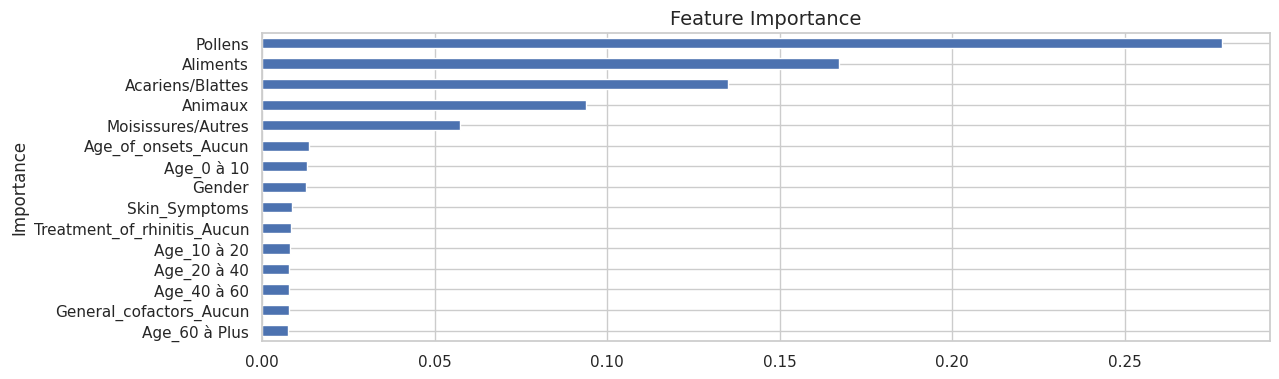

In [12]:
import matplotlib.pyplot as plt

importances = pd.Series(rfc.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Top 15
importances_z = importances[:15]
importances_z = importances_z.sort_values(ascending=True)

# Plot
plt.figure(figsize=(13, 4))
importances_z.plot(kind='barh')
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()